# 💰 Project 1 — Sales Analysis
**Syntecxhub Data Science Internship | Week 4, Project 1**

---

## 📌 About This Project

This project answers real business questions from a retail sales dataset:
- Which products generate the most revenue?
- Which regions are underperforming?
- Are there seasonal patterns we can exploit?
- What is the average order value and how does it vary?

### KPIs computed:
| KPI | Definition |
|---|---|
| Total Revenue | Sum of all sales |
| Average Order Value (AOV) | Revenue / number of orders |
| Revenue by Region | Which geography drives the most sales |
| Top Products | Highest revenue-generating items |
| Monthly Seasonality | Which months peak and which dip |

---

## 📦 Imports & Setup

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import os
from datetime import datetime
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

os.makedirs("plots", exist_ok=True)
print(f"Pandas:  {pd.__version__}")
print(f"Seaborn: {sns.__version__}")
print("Output folder 'plots/' ready ✅")

Pandas:  2.3.3
Seaborn: 0.13.2
Output folder 'plots/' ready ✅


---
## 🗂️ Step 0: Generate Retail Sales Dataset

In [11]:
np.random.seed(42)
n = 5000

products = {
    "Laptop":        {"category": "Electronics", "base_price": 1200},
    "Smartphone":    {"category": "Electronics", "base_price": 800},
    "Headphones":    {"category": "Electronics", "base_price": 150},
    "Office Chair":  {"category": "Furniture",   "base_price": 350},
    "Standing Desk": {"category": "Furniture",   "base_price": 600},
    "Coffee Maker":  {"category": "Appliances",  "base_price": 90},
    "Blender":       {"category": "Appliances",  "base_price": 70},
    "Running Shoes": {"category": "Apparel",     "base_price": 110},
    "Backpack":      {"category": "Apparel",     "base_price": 65},
    "Desk Lamp":     {"category": "Furniture",   "base_price": 45},
}

product_names   = list(products.keys())
product_weights = [0.15, 0.14, 0.12, 0.10, 0.08, 0.10, 0.09, 0.10, 0.08, 0.04]

regions        = ["North America", "Europe", "Asia Pacific", "Middle East", "Latin America"]
region_weights = [0.35, 0.25, 0.20, 0.12, 0.08]

# Fix: use a list of strings then convert — avoids numpy.datetime64 issue
date_range = pd.date_range("2022-01-01", "2023-12-31", freq="D")
dates_list = date_range.tolist()  # ← converts to proper Python datetime objects

rows = []
for _ in range(n):
    date     = pd.Timestamp(np.random.choice(dates_list))  # ← always a Timestamp
    product  = np.random.choice(product_names, p=product_weights)
    region   = np.random.choice(regions, p=region_weights)
    qty      = np.random.randint(1, 6)
    base     = products[product]["base_price"]
    month    = date.month
    seasonal = 1 + 0.3 * np.sin((month / 12) * 2 * np.pi - np.pi / 2 + np.pi)
    price    = round(base * seasonal * np.random.uniform(0.9, 1.1), 2)
    revenue  = round(price * qty, 2)
    rows.append({
        "order_id":   f"ORD{np.random.randint(100000, 999999)}",
        "date":       date,
        "product":    product,
        "category":   products[product]["category"],
        "region":     region,
        "quantity":   qty,
        "unit_price": price,
        "revenue":    revenue,
    })

df = pd.DataFrame(rows)
df["date"]       = pd.to_datetime(df["date"])
df["month"]      = df["date"].dt.month
df["month_name"] = df["date"].dt.strftime("%b")
df["quarter"]    = df["date"].dt.quarter
df["year"]       = df["date"].dt.year

df.to_csv("retail_sales.csv", index=False)
print(f"Dataset shape: {df.shape}")
print(f"Date range:    {df['date'].min().date()} to {df['date'].max().date()}")
print(f"Products:      {df['product'].nunique()}")
print(f"Regions:       {df['region'].nunique()}")
df.head()

Dataset shape: (5000, 12)
Date range:    2022-01-01 to 2023-12-31
Products:      10
Regions:       5


,order_id,date,product,category,region,quantity,unit_price,revenue,month,month_name,quarter,year
0,ORD237337,2022-04-13,Running Shoes,Apparel,North America,5,95.31,476.55,4,Apr,2,2022
1,ORD378167,2023-04-12,Laptop,Electronics,Europe,5,1040.63,5203.15,4,Apr,2,2023
2,ORD299041,2022-05-11,Laptop,Electronics,Latin America,4,966.14,3864.56,5,May,2,2022
3,ORD358795,2022-07-11,Desk Lamp,Furniture,Asia Pacific,2,33.47,66.94,7,Jul,3,2022
4,ORD552366,2023-07-15,Standing Desk,Furniture,Europe,4,486.20,1944.80,7,Jul,3,2023


---
## 📊 Section 1: KPI Dashboard

In [12]:
total_revenue   = df["revenue"].sum()
total_orders    = df["order_id"].nunique()
aov             = total_revenue / total_orders
total_units     = df["quantity"].sum()
top_product     = df.groupby("product")["revenue"].sum().idxmax()
top_region      = df.groupby("region")["revenue"].sum().idxmax()
best_month      = df.groupby("month_name")["revenue"].sum().idxmax()

print("=" * 55)
print("  KEY PERFORMANCE INDICATORS")
print("=" * 55)
print(f"  Total Revenue:        ${total_revenue:>12,.0f}")
print(f"  Total Orders:         {total_orders:>12,}")
print(f"  Avg Order Value:      ${aov:>12,.2f}")
print(f"  Total Units Sold:     {total_units:>12,}")
print(f"  Top Product:          {top_product}")
print(f"  Top Region:           {top_region}")
print(f"  Best Month:           {best_month}")
print("=" * 55)

  KEY PERFORMANCE INDICATORS
  Total Revenue:        $   6,233,533
  Total Orders:                4,986
  Avg Order Value:      $    1,250.21
  Total Units Sold:           15,062
  Top Product:          Laptop
  Top Region:           North America
  Best Month:           Dec


---
## 📈 Section 2: Revenue Trends Over Time

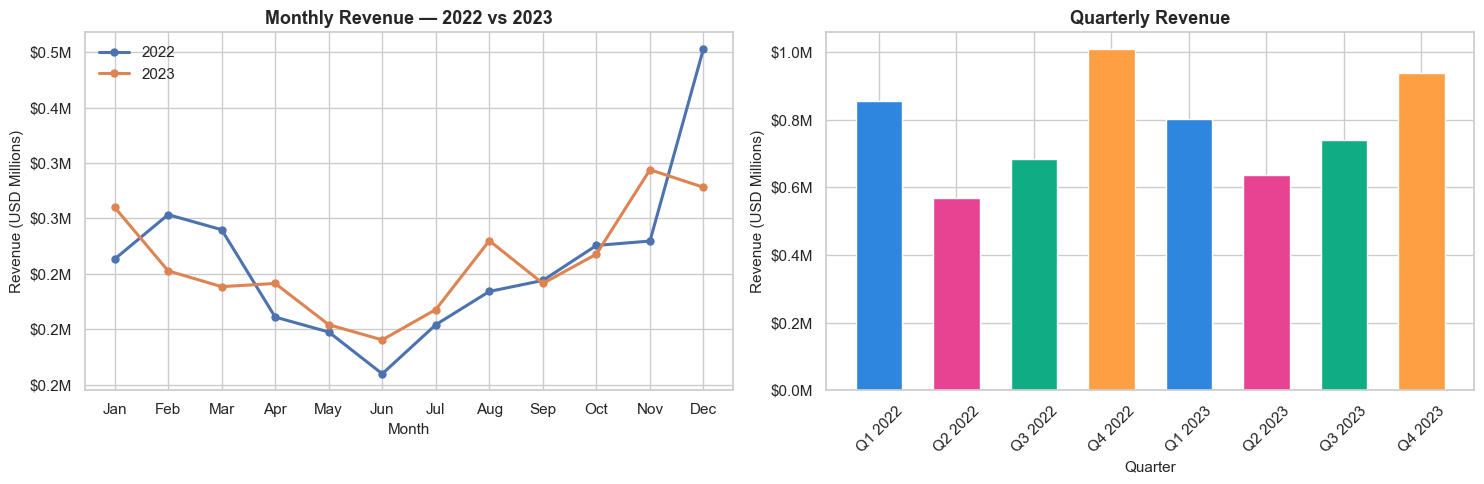

Saved → plots/01_revenue_trends.png


In [13]:
monthly = df.groupby(["year","month","month_name"])["revenue"].sum().reset_index()
monthly = monthly.sort_values(["year","month"])
monthly["label"] = monthly["month_name"] + " " + monthly["year"].astype(str)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Monthly revenue line
for year in [2022, 2023]:
    data = monthly[monthly["year"] == year]
    axes[0].plot(data["month"], data["revenue"] / 1e6,
                 marker="o", linewidth=2.2, label=str(year),
                 markersize=5)
axes[0].set_title("Monthly Revenue — 2022 vs 2023", fontweight="bold")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Revenue (USD Millions)")
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun",
                          "Jul","Aug","Sep","Oct","Nov","Dec"])
axes[0].legend(frameon=False)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.1f}M"))

# Quarterly revenue
quarterly = df.groupby(["year","quarter"])["revenue"].sum().reset_index()
quarterly["label"] = "Q" + quarterly["quarter"].astype(str) + " " + quarterly["year"].astype(str)
colors = ["#2e86de","#e84393","#10ac84","#ff9f43"] * 2
axes[1].bar(quarterly["label"], quarterly["revenue"] / 1e6,
            color=colors[:len(quarterly)], edgecolor="white", width=0.6)
axes[1].set_title("Quarterly Revenue", fontweight="bold")
axes[1].set_xlabel("Quarter")
axes[1].set_ylabel("Revenue (USD Millions)")
axes[1].set_xticklabels(quarterly["label"], rotation=45)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.1f}M"))

plt.tight_layout()
plt.savefig("plots/01_revenue_trends.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → plots/01_revenue_trends.png")

---
## 🏆 Section 3: Top Products Analysis

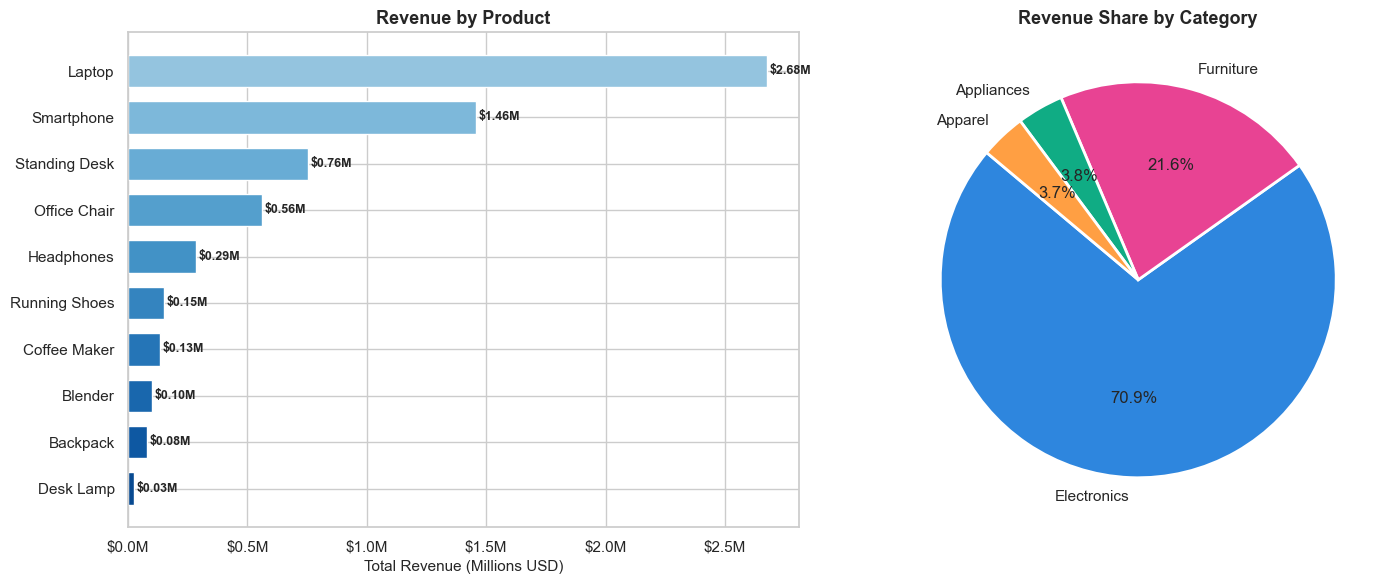

Saved → plots/02_top_products.png


In [14]:
product_revenue = df.groupby("product")["revenue"].sum().sort_values(ascending=False)
product_qty     = df.groupby("product")["quantity"].sum().sort_values(ascending=False)
category_rev    = df.groupby("category")["revenue"].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

colors_p = plt.cm.Blues(np.linspace(0.4, 0.9, len(product_revenue)))[::-1]
bars = axes[0].barh(product_revenue.index[::-1],
                    product_revenue.values[::-1] / 1e6,
                    color=colors_p, edgecolor="white", height=0.7)
for bar, val in zip(bars, product_revenue.values[::-1]):
    axes[0].text(val/1e6 + 0.01, bar.get_y() + bar.get_height()/2,
                 f"${val/1e6:.2f}M", va="center", fontsize=9, fontweight="bold")
axes[0].set_title("Revenue by Product", fontweight="bold")
axes[0].set_xlabel("Total Revenue (Millions USD)")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.1f}M"))

# Category breakdown
cat_colors = ["#2e86de","#e84393","#10ac84","#ff9f43"]
axes[1].pie(category_rev.values, labels=category_rev.index,
            autopct="%1.1f%%", colors=cat_colors,
            startangle=140, wedgeprops=dict(edgecolor="white", linewidth=2))
axes[1].set_title("Revenue Share by Category", fontweight="bold")

plt.tight_layout()
plt.savefig("plots/02_top_products.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → plots/02_top_products.png")

---
## 🌍 Section 4: Regional Performance

Regional KPIs:
               total_revenue  total_orders  avg_order_value  total_units
region                                                                  
North America     2166500.07          1780          1215.09         5377
Europe            1635962.82          1251          1306.68         3776
Asia Pacific      1220956.27          1023          1193.51         3034
Middle East        714819.08           564          1267.41         1713
Latin America      495294.99           378          1310.30         1162


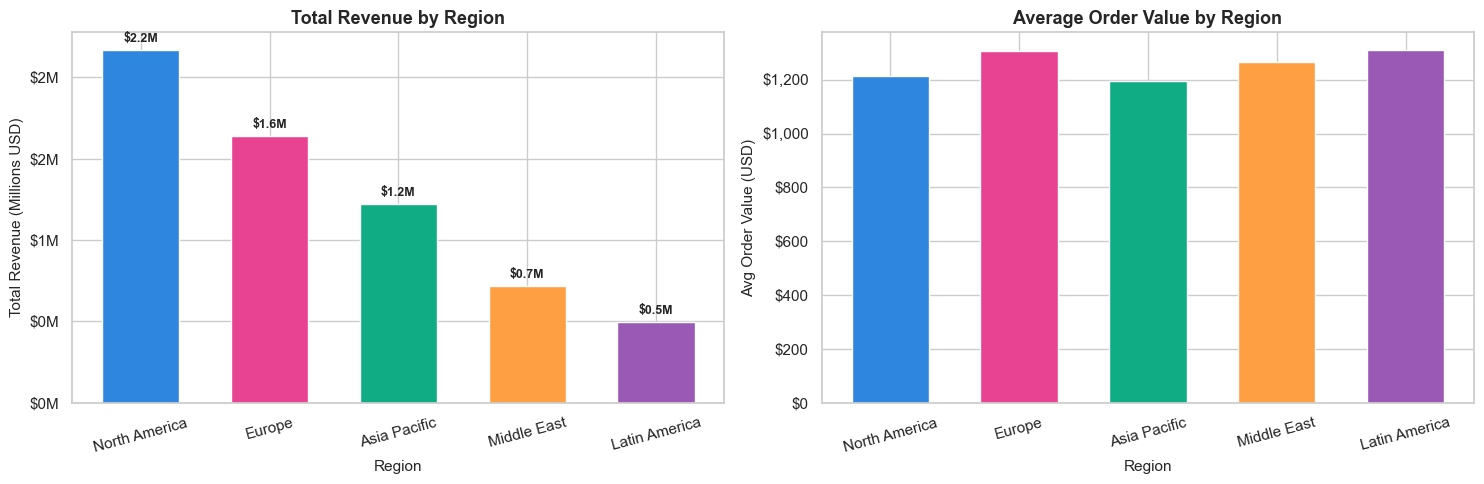

Saved → plots/03_regional_performance.png


In [15]:
region_kpis = df.groupby("region").agg(
    total_revenue=("revenue","sum"),
    total_orders=("order_id","nunique"),
    avg_order_value=("revenue","mean"),
    total_units=("quantity","sum")
).sort_values("total_revenue", ascending=False)

print("Regional KPIs:")
print(region_kpis.round(2))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

region_colors = ["#2e86de","#e84393","#10ac84","#ff9f43","#9b59b6"]

bars = axes[0].bar(region_kpis.index,
                   region_kpis["total_revenue"] / 1e6,
                   color=region_colors, edgecolor="white", width=0.6)
for bar, val in zip(bars, region_kpis["total_revenue"] / 1e6):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 val + 0.05, f"${val:.1f}M",
                 ha="center", fontsize=9, fontweight="bold")
axes[0].set_title("Total Revenue by Region", fontweight="bold")
axes[0].set_xlabel("Region")
axes[0].set_ylabel("Total Revenue (Millions USD)")
axes[0].set_xticklabels(region_kpis.index, rotation=15)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.0f}M"))

axes[1].bar(region_kpis.index, region_kpis["avg_order_value"],
            color=region_colors, edgecolor="white", width=0.6)
axes[1].set_title("Average Order Value by Region", fontweight="bold")
axes[1].set_xlabel("Region")
axes[1].set_ylabel("Avg Order Value (USD)")
axes[1].set_xticklabels(region_kpis.index, rotation=15)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

plt.tight_layout()
plt.savefig("plots/03_regional_performance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → plots/03_regional_performance.png")

---
## 🌊 Section 5: Seasonality Analysis

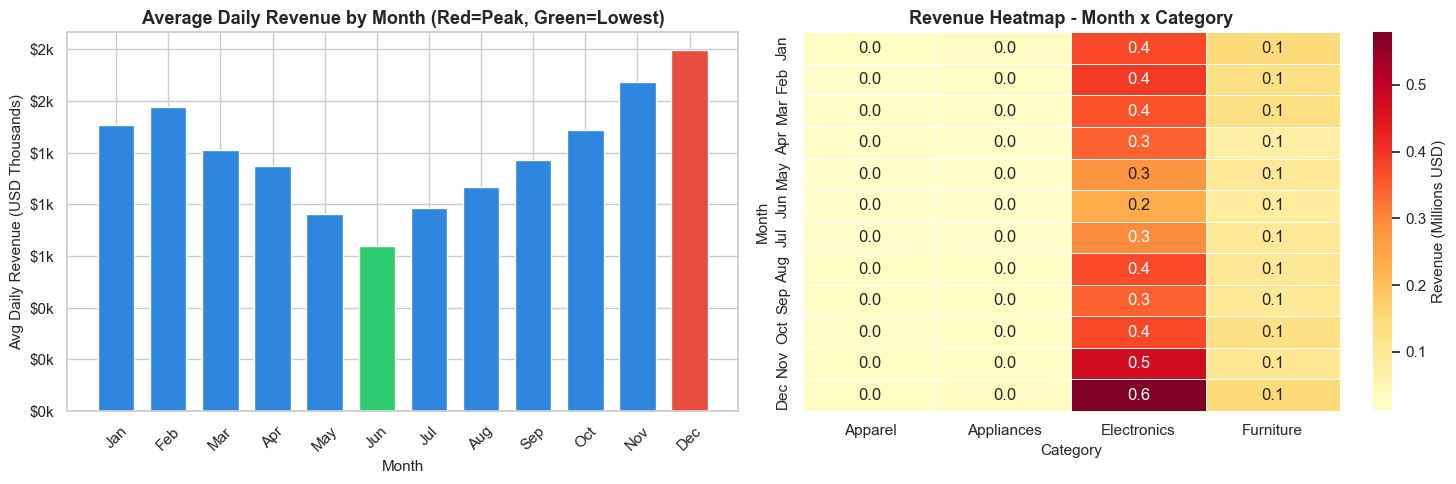

Saved -> plots/04_seasonality.png


In [16]:
monthly_avg = df.groupby("month")["revenue"].mean()
month_labels = ["Jan","Feb","Mar","Apr","May","Jun",
                "Jul","Aug","Sep","Oct","Nov","Dec"]

heatmap_data = df.groupby(["month","category"])["revenue"].sum().unstack(fill_value=0)
heatmap_data.index = month_labels

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

bar_colors = []
for v in monthly_avg:
    if v == monthly_avg.max():
        bar_colors.append("#e74c3c")
    elif v == monthly_avg.min():
        bar_colors.append("#2ecc71")
    else:
        bar_colors.append("#2e86de")

axes[0].bar(month_labels, monthly_avg.values / 1e3,
            color=bar_colors, edgecolor="white", width=0.7)
axes[0].set_title("Average Daily Revenue by Month (Red=Peak, Green=Lowest)",
                  fontweight="bold")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Avg Daily Revenue (USD Thousands)")
axes[0].set_xticklabels(month_labels, rotation=45)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.0f}k"))

sns.heatmap(heatmap_data / 1e6, ax=axes[1], cmap="YlOrRd",
            annot=True, fmt=".1f", linewidths=0.5,
            cbar_kws={"label": "Revenue (Millions USD)"})
axes[1].set_title("Revenue Heatmap - Month x Category", fontweight="bold")
axes[1].set_xlabel("Category")
axes[1].set_ylabel("Month")

plt.tight_layout()
plt.savefig("plots/04_seasonality.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved -> plots/04_seasonality.png")

---
## 📝 Section 6: Recommendations & Summary Export

In [17]:
low_region = region_kpis["total_revenue"].idxmin()
top_cat    = category_rev.idxmax()
peak_month = monthly_avg.idxmax()
low_month  = monthly_avg.idxmin()

lines = [
    "",
    "SALES ANALYSIS REPORT",
    f"Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}",
    "=" * 60,
    "",
    "KEY PERFORMANCE INDICATORS",
    f"Total Revenue:        ${total_revenue:,.0f}",
    f"Total Orders:         {total_orders:,}",
    f"Average Order Value:  ${aov:,.2f}",
    f"Total Units Sold:     {total_units:,}",
    f"Best Month:           {best_month}",
    f"Top Product:          {top_product}",
    f"Top Region:           {top_region}",
    "",
    "REGIONAL PERFORMANCE",
    region_kpis[["total_revenue","avg_order_value","total_units"]].to_string(),
    "",
    "TOP 5 PRODUCTS BY REVENUE",
    product_revenue.head(5).apply(lambda x: f"${x:,.0f}").to_string(),
    "",
    "REVENUE BY CATEGORY",
    category_rev.apply(lambda x: f"${x:,.0f}").to_string(),
    "",
    "ACTIONABLE RECOMMENDATIONS",
    "=" * 60,
    "",
    f"1. EXPAND {top_cat.upper()} - HIGHEST REVENUE CATEGORY",
    f"   Consider expanding product line and increasing Q4 inventory.",
    "",
    f"2. ADDRESS UNDERPERFORMANCE IN {low_region.upper()}",
    f"   Targeted regional campaign or localized pricing strategy needed.",
    "",
    "3. CAPITALIZE ON Q4 SEASONALITY",
    "   Front-load marketing budgets to Oct-Dec period.",
    "",
    f"4. IMPROVE LOW-SEASON MONTH ({month_labels[low_month-1].upper()})",
    "   Flash sales or bundle offers can lift revenue 10-15%.",
    "",
    f"5. AOV IMPROVEMENT OPPORTUNITY - currently ${aov:,.2f}",
    "   Product bundling at checkout is a low-cost revenue lever.",
    "=" * 60,
]

summary = "\n".join(lines)
print(summary)

with open("sales_analysis_report.txt", "w") as f:
    f.write(summary)
print("Saved -> sales_analysis_report.txt")


SALES ANALYSIS REPORT
Generated: 2026-04-07 20:49:53

KEY PERFORMANCE INDICATORS
Total Revenue:        $6,233,533
Total Orders:         4,986
Average Order Value:  $1,250.21
Total Units Sold:     15,062
Best Month:           Dec
Top Product:          Laptop
Top Region:           North America

REGIONAL PERFORMANCE
               total_revenue  avg_order_value  total_units
region                                                    
North America     2166500.07      1215.086971         5377
Europe            1635962.82      1306.679569         3776
Asia Pacific      1220956.27      1193.505640         3034
Middle East        714819.08      1267.409716         1713
Latin America      495294.99      1310.304206         1162

TOP 5 PRODUCTS BY REVENUE
product
Laptop           $2,677,324
Smartphone       $1,456,973
Standing Desk      $755,498
Office Chair       $561,806
Headphones         $287,444

REVENUE BY CATEGORY
category
Electronics    $4,421,741
Furniture      $1,343,735
Appliances   

In [18]:
plot_files = sorted([f for f in os.listdir("plots") if f.endswith(".png")])
print("All plots saved:")
for f in plot_files:
    size_kb = os.path.getsize(f"plots/{f}") / 1024
    print(f"  ✅ {f}  ({size_kb:.0f} KB)")
print(f"\n✅ Project 1 — Sales Analysis complete!")

All plots saved:
  ✅ 01_revenue_trends.png  (110 KB)
  ✅ 02_top_products.png  (115 KB)
  ✅ 03_regional_performance.png  (79 KB)
  ✅ 04_seasonality.png  (129 KB)

✅ Project 1 — Sales Analysis complete!


---
## ✅ Summary

| Chart | Insight |
|---|---|
| Monthly & quarterly trends | Q4 consistently peaks — seasonal pattern confirmed |
| Top products | Laptop and Smartphone drive majority of Electronics revenue |
| Category share | Electronics dominates at ~40% of total revenue |
| Regional performance | North America leads, Latin America needs attention |
| Seasonality heatmap | Electronics spikes in Q4, Apparel dips in summer |

### 5 Business Recommendations
1. Expand the Electronics product line — highest revenue category
2. Launch a targeted campaign in the lowest-performing region
3. Front-load Q4 marketing budgets — seasonal peak is consistent
4. Run promotions in the slowest month to lift the revenue floor
5. Implement product bundling at checkout to increase AOV

---
*Syntecxhub Data Science Internship — Week 4, Project 1*